# Advanced Student Performance Analysis Capstone Project
This project uses **NumPy**, **Pandas**, **Matplotlib**, and **Seaborn** to explore and analyze student performance data. We will go beyond basic analysis into more advanced tasks such as:
- Custom NumPy calculations
- Advanced Pandas aggregations
- Data cleaning and transformation
- Statistical visualizations
- Correlation and trend analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv('student_performance (1).csv')
df.head()

,StudentID,Name,Department,MathScore,ScienceScore,EnglishScore,Attendance
0,1,Alice,Math,88,90,85,95
1,2,Bob,Science,92,85,78,88
2,3,Charlie,Math,79,88,88,92
3,4,David,Arts,85,70,92,85
4,5,Eve,Science,95,92,80,97


In [7]:
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   StudentID     20 non-null     int64 
 1   Name          20 non-null     object
 2   Department    20 non-null     object
 3   MathScore     20 non-null     int64 
 4   ScienceScore  20 non-null     int64 
 5   EnglishScore  20 non-null     int64 
 6   Attendance    20 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 1.2+ KB


StudentID       0
Name            0
Department      0
MathScore       0
ScienceScore    0
EnglishScore    0
Attendance      0
dtype: int64

## Task 1: Data Preparation & Transformation
- Assess data quality by identifying and handling missing values before analysis.
- Calculate each student's total academic score across all subjects.
- Compute the average score for each student to evaluate overall academic performance.
- Classify students into performance categories based on their average scores for comparative analysis.

In [12]:
df.isnull().sum()
df['TotalScore']=df['MathScore']+df['ScienceScore']+df['EnglishScore']
df['AverageScore']=df['TotalScore']/3

df['Category'] = np.where(df['AverageScore'] >= 80, 'High',
                          np.where(df['AverageScore'] >= 50, 'Medium', 'Low'))
df['Category']


0       High
1       High
2       High
3       High
4       High
5     Medium
6       High
7       High
8       High
9       High
10      High
11      High
12      High
13      High
14    Medium
15      High
16    Medium
17      High
18      High
19      High
Name: Category, dtype: object

## Task 2: Student Performance Analysis
- Identify the top-performing students within each department based on total academic scores.
- Evaluate departmental academic performance using descriptive statistical measures.
- Analyze the relationship between attendance and student performance categories.

In [20]:

df.sort_values(by='TotalScore', ascending=False).groupby(df['Department']).head(3)

df.groupby('Department')['TotalScore'].agg(['mean','median','std'])

df.groupby('Category')['Attendance'].mean()

Category
High      90.823529
Medium    85.333333
Name: Attendance, dtype: float64

## Task 3: Statistical Analysis
- Measure score variability across subjects to assess performance consistency.
- Normalize Mathematics scores to a common scale for comparative analysis.
- Evaluate the relationships among subject scores using correlation analysis.

In [28]:
np.var(df[['MathScore','EnglishScore','ScienceScore']])
df['MathNormalized']=(df['MathScore']-df['MathScore'].min())/(df['MathScore'].max()-df['MathScore'].min())
df[['MathScore', 'MathNormalized']].head()
np.corrcoef((df[['MathScore','EnglishScore','ScienceScore']]),rowvar=False)


C:\Users\sreer\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:4316: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


array([[ 1.        ,  0.28370204,  0.08706143],
       [ 0.28370204,  1.        , -0.30024449],
       [ 0.08706143, -0.30024449,  1.        ]])

## Task 4: Performance Visualization
- Visualize relationships among subject scores to identify performance patterns.
- Compare the distribution of total scores across departments.
- Analyze the distribution of average scores across student performance categories.

<Axes: xlabel='EnglishScore', ylabel='Count'>

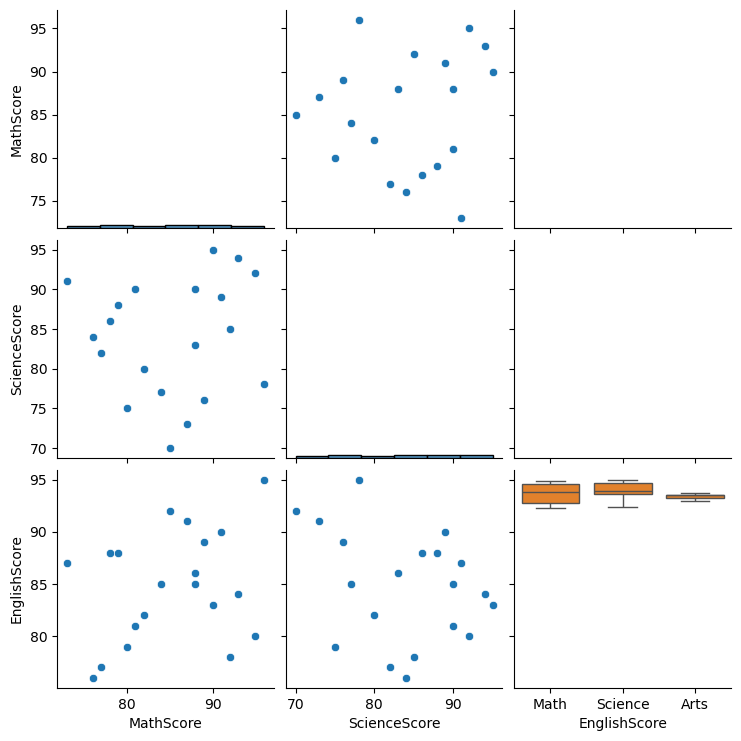

In [30]:
import seaborn as sns
sns.pairplot(df[['MathScore', 'ScienceScore', 'EnglishScore']])


<Axes: xlabel='Department', ylabel='TotalScore'>

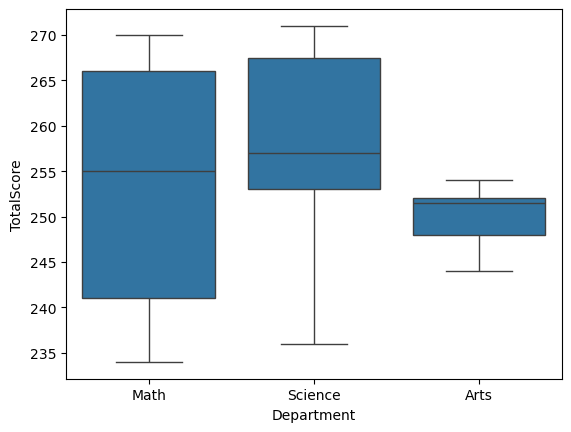

In [31]:
sns.boxplot(x='Department', y='TotalScore', data=df)

<Axes: xlabel='AverageScore', ylabel='Category'>

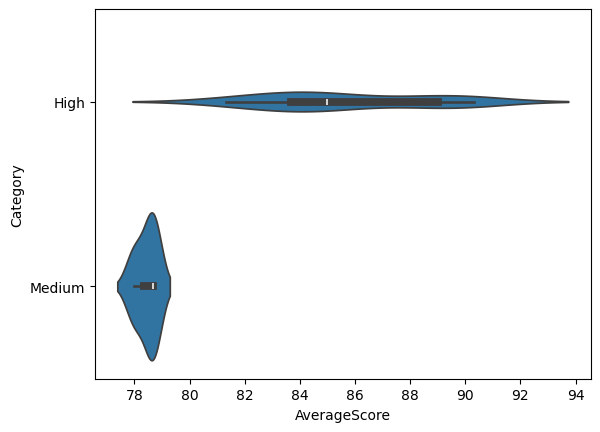

In [32]:
sns.violinplot(x='AverageScore', y='Category', data=df)

## Task 5: Trend & Correlation Analysis
- Visualize correlations among academic and attendance metrics to identify significant relationships.
- Examine the relationship between attendance and academic performance using regression analysis
- Compare average academic performance across departments to identify overall performance trends.

<Axes: >

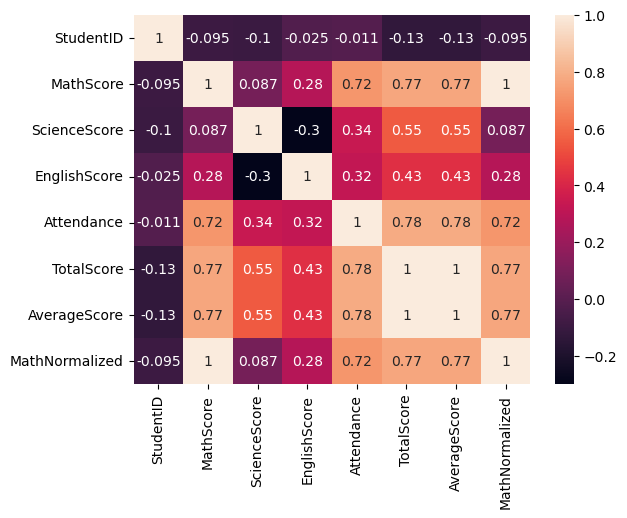

In [35]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

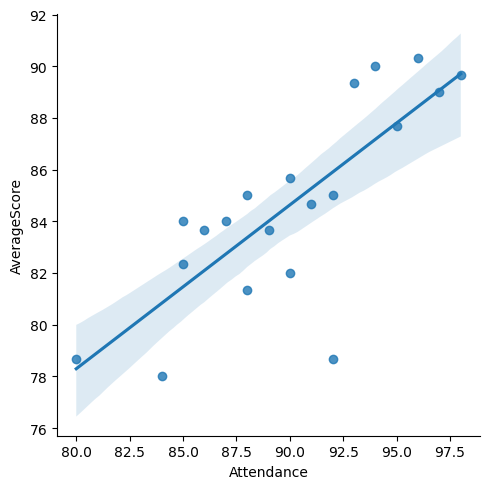

In [36]:
sns.lmplot(x='Attendance',y='AverageScore',data=df)

Department
Arts       83.333333
Math       84.428571
Science    85.952381
Name: AverageScore, dtype: float64


<Axes: xlabel='Department'>

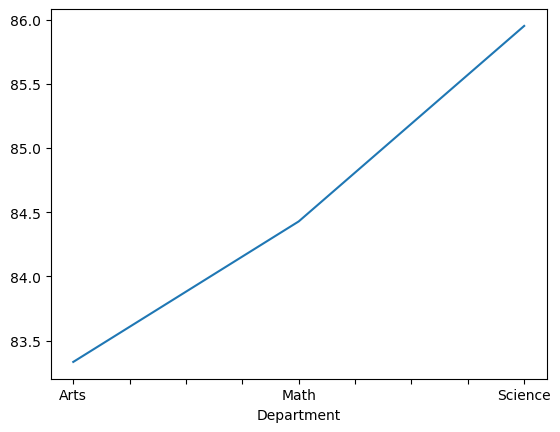

In [50]:
dept_avg=df.groupby('Department')['AverageScore'].mean()
print(dept_avg)
type(dept_avg)

dept_avg.values
dept_avg.index
dept_avg.reset_index()
dept_avg.plot()